# 🧠 Machine Learning Visualization Worksheet


This worksheet provides interactive visualizations for key concepts:
1. **Supervised vs. Unsupervised Learning** - Compare how algorithms learn from labeled vs. unlabeled data.
2. **Linear Regression Model** - Visualize how a line fits housing price data.
3. **Cost Function (3D Surface)** - See how the cost function \( J(w,b) \) changes with parameters.
4. **Gradient Descent Path** - Watch the optimization algorithm find the minimum.

> Each cell below contains a complete, runnable visualization. Adjust parameters to explore the concepts!

## 📦 1. Import Libraries & Setup
*Run this cell first to import all necessary libraries.*

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from IPython.display import HTML

# Set style for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📊 2. Supervised vs. Unsupervised Learning
*This interactive chart contrasts how supervised learning finds boundaries using labels vs. unsupervised learning discovers natural clusters.*

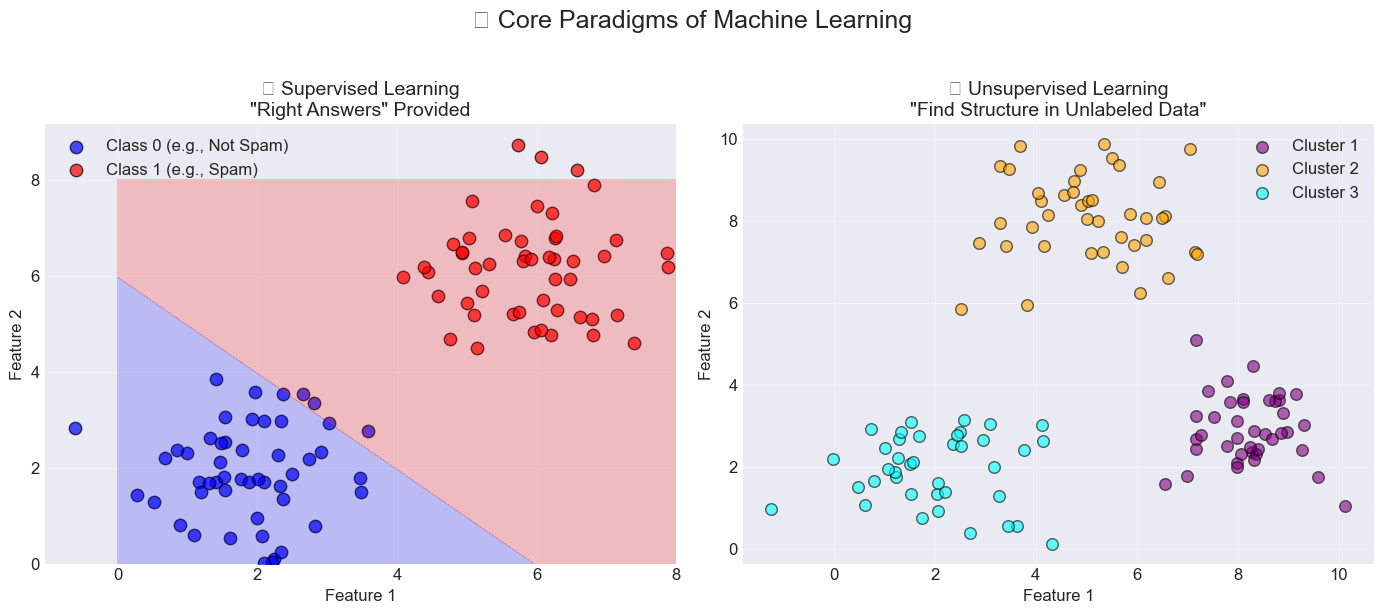

In [ ]:
# Generate synthetic data
np.random.seed(42)
# Supervised: Two classes with labels
X_sup_1 = np.random.randn(50, 2) + [2, 2]
X_sup_2 = np.random.randn(50, 2) + [6, 6]
X_sup = np.vstack([X_sup_1, X_sup_2])
y_sup = np.array([0]*50 + [1]*50)

# Unsupervised: Three natural clusters
X_unsup = np.vstack([
    np.random.randn(40, 2) + [2, 2],
    np.random.randn(40, 2) + [8, 3],
    np.random.randn(40, 2) + [5, 8]
])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Supervised Learning Plot
axes[0].scatter(X_sup[y_sup==0, 0], X_sup[y_sup==0, 1], c='blue', label='Class 0 (e.g., Not Spam)', s=80, edgecolor='k', alpha=0.7)
axes[0].scatter(X_sup[y_sup==1, 0], X_sup[y_sup==1, 1], c='red', label='Class 1 (e.g., Spam)', s=80, edgecolor='k', alpha=0.7)
# Draw a decision boundary
xx, yy = np.meshgrid(np.linspace(0, 8, 50), np.linspace(0, 8, 50))
Z = (xx + yy - 6) > 0
axes[0].contourf(xx, yy, Z, alpha=0.2, colors=['blue', 'red'])
axes[0].set_title('🔵 Supervised Learning\n"Right Answers" Provided', fontsize=14)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Unsupervised Learning Plot
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_unsup)
colors = ['purple', 'orange', 'cyan']
for i in range(3):
    axes[1].scatter(X_unsup[clusters==i, 0], X_unsup[clusters==i, 1],
                    c=colors[i], label=f'Cluster {i+1}', s=70, alpha=0.6, edgecolor='k')
axes[1].set_title('🟢 Unsupervised Learning\n"Find Structure in Unlabeled Data"', fontsize=14)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('🧠 Core Paradigms of Machine Learning', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## 🏠 3. Linear Regression: Housing Price Prediction
*This visualization shows how a linear model \( f(x) = wx + b \) fits real-world housing data.*

In [ ]:
# Housing price dataset (size in sq ft, price in $1000s)
X_house = np.array([500, 800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000, 3500, 4000])
y_house = np.array([150, 200, 240, 280, 330, 380, 420, 460, 520, 580, 620, 720, 820])

# Calculate optimal parameters using closed-form solution (Normal Equation)
X_mean = np.mean(X_house)
y_mean = np.mean(y_house)
w_optimal = np.sum((X_house - X_mean) * (y_house - y_mean)) / np.sum((X_house - X_mean)**2)
b_optimal = y_mean - w_optimal * X_mean

# Calculate predictions and error metrics
y_pred_optimal = w_optimal * X_house + b_optimal
errors = y_house - y_pred_optimal
mse = np.mean(errors**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(errors))
r2 = 1 - np.sum(errors**2) / np.sum((y_house - y_mean)**2)

# Calculate correlation
correlation = np.corrcoef(X_house, y_house)[0, 1]

# Print detailed quantitative results
print("=" * 70)
print("🏠 LINEAR REGRESSION - HOUSING PRICE PREDICTION")
print("=" * 70)
print(f"📊 Dataset Statistics:")
print(f"   • Number of houses: {len(X_house)}")
print(f"   • Size range: {X_house.min():.0f} - {X_house.max():.0f} sq ft")
print(f"   • Size mean: {X_mean:.1f} sq ft")
print(f"   • Price range: ${y_house.min():.0f}k - ${y_house.max():.0f}k")
print(f"   • Price mean: ${y_mean:.1f}k")
print(f"   • Correlation between size and price: {correlation:.4f}")

print(f"\n📈 OPTIMAL MODEL (Best Fit):")
print(f"   f(x) = {w_optimal:.4f}x + {b_optimal:.2f}")
print(f"   where x = house size (sq ft), output = price ($1000s)")

print(f"\n📊 ERROR METRICS:")
print(f"   • Mean Squared Error (MSE): {mse:.2f}")
print(f"   • Root Mean Squared Error (RMSE): {rmse:.2f} ($1000s)")
print(f"   • Mean Absolute Error (MAE): {mae:.2f} ($1000s)")
print(f"   • R² Score: {r2:.4f}")
print(f"     (1.0 = perfect fit, 0 = random guess, <0 = worse than mean)")

print(f"\n🔮 Sample Predictions (using optimal model):")
test_sizes = [750, 1250, 2000, 3000, 4500]
for size in test_sizes:
    pred = w_optimal * size + b_optimal
    actual_idx = np.where(X_house == size)[0]
    if len(actual_idx) > 0:
        actual = y_house[actual_idx[0]]
        error = pred - actual
        print(f"   🏠 {size} sq ft → ${pred:.0f}k (Actual: ${actual:.0f}k, Error: ${error:+.0f}k)")
    else:
        print(f"   🏠 {size} sq ft → ${pred:.0f}k (No actual data point)")

print(f"\n📐 Model Interpretation:")
print(f"   • Each additional 100 sq ft → ${w_optimal*100:.1f}k price increase")
print(f"   • Base price (0 sq ft): ${b_optimal:.1f}k (theoretical intercept)")
print(f"   • R² = {r2:.3f} means {r2*100:.1f}% of price variance is explained by house size")

# Create interactive plot with Plotly
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(x=X_house, y=y_house, mode='markers',
                         name='Training Data',
                         marker=dict(size=14, color='darkblue', symbol='circle',
                                    line=dict(color='white', width=1.5)),
                         hovertemplate='<b>House Details</b><br>' +
                                       'Size: %{x} ft²<br>' +
                                       'Price: $%{y}k<br>' +
                                       '<extra></extra>'))

# Add optimal regression line
x_line = np.linspace(400, 4200, 100)
y_line_optimal = w_optimal * x_line + b_optimal
fig.add_trace(go.Scatter(x=x_line, y=y_line_optimal, mode='lines',
                         name=f'✅ Optimal Model: f(x) = {w_optimal:.3f}x + {b_optimal:.1f}',
                         line=dict(color='red', width=4, dash='solid'),
                         hovertemplate='Prediction: $%{{y:.0f}}k<extra></extra>'))

# Add initial/sample lines for comparison
w_init, b_init = 0.2, 50
y_line_init = w_init * x_line + b_init
fig.add_trace(go.Scatter(x=x_line, y=y_line_init, mode='lines',
                         name=f'Initial Guess: f(x) = {w_init:.1f}x + {b_init:.0f}',
                         line=dict(color='gray', width=2, dash='dash'),
                         opacity=0.6))

# Add error bands (95% confidence interval)
std_error = np.std(errors)
y_upper = y_line_optimal + 1.96 * std_error
y_lower = y_line_optimal - 1.96 * std_error
fig.add_trace(go.Scatter(x=np.concatenate([x_line, x_line[::-1]]),
                         y=np.concatenate([y_upper, y_lower[::-1]]),
                         fill='toself',
                         fillcolor='rgba(255,0,0,0.15)',
                         line=dict(color='rgba(255,0,0,0)'),
                         name='95% Confidence Interval',
                         hoverinfo='skip'))

# Add residual lines (vertical from points to line)
for i in range(len(X_house)):
    fig.add_trace(go.Scatter(x=[X_house[i], X_house[i]],
                             y=[y_house[i], y_pred_optimal[i]],
                             mode='lines',
                             line=dict(color='rgba(255,0,0,0.3)', width=1, dash='dot'),
                             showlegend=False,
                             hoverinfo='skip'))

# Update layout with sliders for interactive exploration
fig.update_layout(
    title={
        'text': '🏡 Linear Regression Model: House Price Prediction',
        'font': {'size': 20, 'family': 'Arial Black'},
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis_title='House Size (square feet)',
    yaxis_title='Price ($1000s)',
    hovermode='closest',
    template='plotly_white',
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.9)', bordercolor='black', borderwidth=1),
    annotations=[
        dict(text=f'<b>Model Performance</b><br>R² = {r2:.3f}<br>RMSE = ${rmse:.0f}k<br>MAE = ${mae:.0f}k',
             x=0.98, y=0.98, xref='paper', yref='paper',
             showarrow=False, font=dict(size=12),
             bgcolor='rgba(255,255,255,0.9)', bordercolor='black', borderwidth=1,
             xanchor='right', yanchor='top'),
        dict(text=f'<b>Optimal Parameters</b><br>w = {w_optimal:.4f}<br>b = {b_optimal:.2f}',
             x=0.02, y=0.98, xref='paper', yref='paper',
             showarrow=False, font=dict(size=12),
             bgcolor='rgba(255,255,255,0.9)', bordercolor='black', borderwidth=1,
             xanchor='left', yanchor='top')
    ],
    sliders=[
        dict(
            active=0,
            steps=[dict(method='update',
                        label=f'{w/10:.2f}',
                        args=[{'line.color': ['red', 'gray'],
                               'line.width': [4, 2],
                               'name': [f'Custom: f(x) = {w/10:.2f}x + {b_init:.0f}', 'Initial Guess'],
                               'y': [w/10 * x_line + b_init, y_line_init]}])
                  for w in range(-10, 31, 2)],
            currentvalue=dict(prefix='🔧 Explore Different Slopes (w): ',
                            font=dict(size=14, color='darkblue')),
            pad=dict(t=50),
            len=0.9,
            x=0.1,
            y=0
        )
    ]
)

fig.show()

print("\n💡 KEY INSIGHTS:")
print(f"   • The optimal slope (w = {w_optimal:.4f}) means price increases by ${w_optimal*100:.1f}k per 100 sq ft")
print(f"   • R² = {r2:.3f} indicates a {'very strong' if r2 > 0.9 else 'strong' if r2 > 0.7 else 'moderate'} linear relationship")
print(f"   • Typical prediction error is ±${rmse:.0f}k (RMSE)")
print(f"   • The model explains {r2*100:.1f}% of the variance in house prices")
print(f"   • Use the slider above to see how different slopes affect the fit!")

🏠 LINEAR REGRESSION - HOUSING PRICE PREDICTION
📊 Dataset Statistics:
   • Number of houses: 13
   • Size range: 500 - 4000 sq ft
   • Size mean: 2061.5 sq ft
   • Price range: $150k - $820k
   • Price mean: $440.0k
   • Correlation between size and price: 0.9996

📈 OPTIMAL MODEL (Best Fit):
   f(x) = 0.1916x + 45.11
   where x = house size (sq ft), output = price ($1000s)

📊 ERROR METRICS:
   • Mean Squared Error (MSE): 34.59
   • Root Mean Squared Error (RMSE): 5.88 ($1000s)
   • Mean Absolute Error (MAE): 5.00 ($1000s)
   • R² Score: 0.9991
     (1.0 = perfect fit, 0 = random guess, <0 = worse than mean)

🔮 Sample Predictions (using optimal model):
   🏠 750 sq ft → $189k (No actual data point)
   🏠 1250 sq ft → $285k (No actual data point)
   🏠 2000 sq ft → $428k (Actual: $420k, Error: $+8k)
   🏠 3000 sq ft → $620k (Actual: $620k, Error: $-0k)
   🏠 4500 sq ft → $907k (No actual data point)

📐 Model Interpretation:
   • Each additional 100 sq ft → $19.2k price increase
   • Base price


💡 KEY INSIGHTS:
   • The optimal slope (w = 0.1916) means price increases by $19.2k per 100 sq ft
   • R² = 0.999 indicates a very strong linear relationship
   • Typical prediction error is ±$6k (RMSE)
   • The model explains 99.9% of the variance in house prices
   • Use the slider above to see how different slopes affect the fit!


### 💡 Explanation:
- **Slope (w)**: Controls how steep the line is. A higher slope means price increases faster with size.
- **Intercept (b)**: The base price when size is zero (conceptually).
- The **goal of linear regression** is to find the \( w \) and \( b \) that make the line pass as close as possible to all data points.

## 🎯 4. Cost Function \( J(w,b) \) - 3D Visualization
*The cost function measures how wrong our model is. This 3D surface plot shows \( J(w,b) \) for different parameter values.*

In [ ]:
# Generate cost surface data
w_vals = np.linspace(-0.5, 1.5, 50)
b_vals = np.linspace(-100, 300, 50)
W, B = np.meshgrid(w_vals, b_vals)
J_vals = np.zeros_like(W)

# Simple dataset for cost calculation
X_cost = np.array([1, 2, 3])
y_cost = np.array([300, 500, 700])

for i in range(len(w_vals)):
    for j in range(len(b_vals)):
        f_wb = W[i,j] * X_cost + B[i,j]
        J_vals[i,j] = (1/(2*len(X_cost))) * np.sum((f_wb - y_cost)**2)

# Create 3D surface plot
fig = go.Figure(data=[go.Surface(z=J_vals, x=w_vals, y=b_vals,
                                 colorscale='Viridis', opacity=0.9,
                                 colorbar=dict(title='Cost J(w,b)'))])

fig.update_layout(
    title='🎯 Cost Function J(w,b) - 3D Surface Plot',
    scene=dict(
        xaxis_title='w (Slope)',
        yaxis_title='b (Intercept)',
        zaxis_title='Cost J(w,b)',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    width=900, height=700
)

# Add a marker for the minimum point
min_idx = np.unravel_index(np.argmin(J_vals), J_vals.shape)
fig.add_trace(go.Scatter3d(x=[w_vals[min_idx[0]]], y=[b_vals[min_idx[1]]], z=[np.min(J_vals)],
                           mode='markers', marker=dict(size=8, color='red'), name='Minimum Point'))

fig.show()

### 💡 Explanation:
- The **cost function** \( J(w,b) = \frac{1}{2m} \sum (f_{w,b}(x^{(i)}) - y^{(i)})^2 \) penalizes large errors.
- The **red dot** indicates the minimum cost - where the model best fits the data.

## ⬇️ 5. Gradient Descent in Action
*Gradient descent iteratively updates parameters to reduce the cost.*

In [5]:
# Simple quadratic cost function: J(w) = (w - 2)^2
def cost_function(w):
    return (w - 2)**2

def gradient(w):
    return 2 * (w - 2)

# Gradient descent parameters
w_history = [0.0]
learning_rate = 0.3
steps = 15

for _ in range(steps):
    w_current = w_history[-1]
    w_new = w_current - learning_rate * gradient(w_current)
    w_history.append(w_new)

w_vals_gd = np.linspace(-1, 5, 200)
cost_vals = cost_function(w_vals_gd)

# Create animated plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(w_vals_gd, cost_vals, 'b-', linewidth=2, label='Cost Function J(w)')
ax.set_xlabel('w (Parameter)', fontsize=12)
ax.set_ylabel('J(w) (Cost)', fontsize=12)
ax.set_title('⬇️ Gradient Descent: Minimizing the Cost Function', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

point, = ax.plot([], [], 'ro', markersize=10, label='Current w')
line, = ax.plot([], [], 'r--', alpha=0.5)

def update(frame):
    point.set_data([w_history[frame]], [cost_function(w_history[frame])])
    if frame > 0:
        line.set_data(w_history[:frame+1], [cost_function(w) for w in w_history[:frame+1]])
    else:
        line.set_data([], [])
    ax.set_title(f'⬇️ Gradient Descent: Step {frame} | w = {w_history[frame]:.3f} | J = {cost_function(w_history[frame]):.3f}')
    return point, line

ani = FuncAnimation(fig, update, frames=len(w_history), interval=500, repeat=True, blit=True)
plt.close()
HTML(ani.to_jshtml())

### 💡 Explanation:
- **Gradient descent** repeats: \( w = w - \alpha \frac{\partial}{\partial w} J(w) \)
- The **learning rate (α)** controls step size (here α = 0.3).
- At each step, the algorithm moves **downhill** until it reaches the minimum.

## 📈 6. Batch Gradient Descent for Linear Regression
*This final visualization shows the complete training process.*

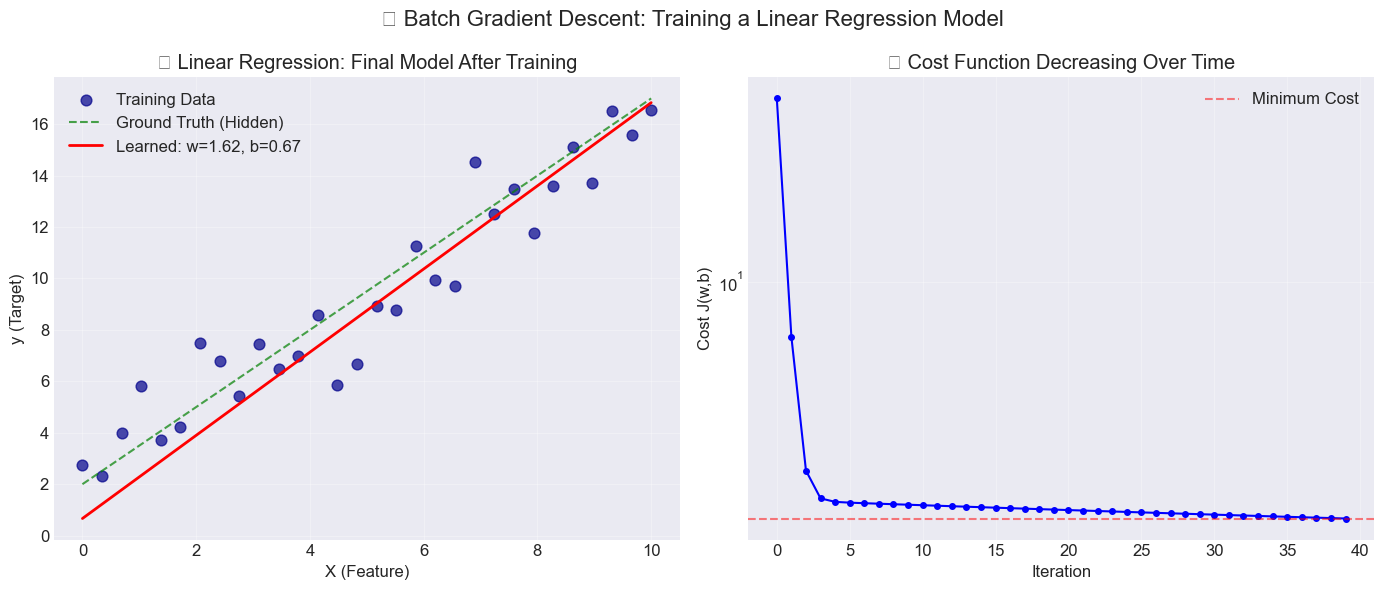

📊 Final Parameters: w = 1.617, b = 0.665
📊 Ground Truth: w = 1.500, b = 2.000
📊 Final Cost: 1.215


In [ ]:
# Generate data
np.random.seed(42)
X_bgd = np.linspace(0, 10, 30)
true_w, true_b = 1.5, 2
y_bgd = true_w * X_bgd + true_b + np.random.randn(30) * 1.5

# Gradient descent setup
w_gd, b_gd = 0.0, 0.0
alpha = 0.02
iterations = 40
history_w, history_b, history_cost = [], [], []

for i in range(iterations):
    y_pred = w_gd * X_bgd + b_gd
    cost = (1/(2*len(X_bgd))) * np.sum((y_pred - y_bgd)**2)
    history_w.append(w_gd)
    history_b.append(b_gd)
    history_cost.append(cost)

    dw = (1/len(X_bgd)) * np.sum((y_pred - y_bgd) * X_bgd)
    db = (1/len(X_bgd)) * np.sum(y_pred - y_bgd)

    w_gd -= alpha * dw
    b_gd -= alpha * db

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Data and final model
ax1.scatter(X_bgd, y_bgd, c='darkblue', alpha=0.7, label='Training Data', s=60)
x_line = np.linspace(0, 10, 100)
y_final = true_w * x_line + true_b
y_learned = w_gd * x_line + b_gd
ax1.plot(x_line, y_final, 'g--', label='Ground Truth (Hidden)', alpha=0.7)
ax1.plot(x_line, y_learned, 'r-', linewidth=2, label=f'Learned: w={w_gd:.2f}, b={b_gd:.2f}')
ax1.set_xlabel('X (Feature)')
ax1.set_ylabel('y (Target)')
ax1.set_title('📈 Linear Regression: Final Model After Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Cost over time
ax2.plot(range(iterations), history_cost, 'b-o', markersize=4, linewidth=1.5)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Cost J(w,b)')
ax2.set_title('📉 Cost Function Decreasing Over Time')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=min(history_cost), color='r', linestyle='--', alpha=0.5, label='Minimum Cost')
ax2.legend()

plt.suptitle('🔄 Batch Gradient Descent: Training a Linear Regression Model', fontsize=16)
plt.tight_layout()
plt.show()

print(f"📊 Final Parameters: w = {w_gd:.3f}, b = {b_gd:.3f}")
print(f"📊 Ground Truth: w = {true_w:.3f}, b = {true_b:.3f}")
print(f"📊 Final Cost: {history_cost[-1]:.3f}")

### 💡 Explanation:
- **Batch Gradient Descent** uses all training examples to compute the gradient at each step.
- The left plot shows the final linear model (red line) compared to the hidden ground truth (green dashed).
- The right plot shows the **cost decreasing exponentially** - this is what we want to see during successful training.

## 🎓 Summary of Key Concepts

| Concept | Definition |
|---------|------------|
| **Supervised Learning** | Learning from labeled "right answers" |
| **Unsupervised Learning** | Finding structure in unlabeled data |
| **Linear Regression** | Model: \( f_{w,b}(x) = wx + b \) |
| **Cost Function** | \( J(w,b) = \frac{1}{2m} \sum (f(x^{(i)}) - y^{(i)})^2 \) |
| **Gradient Descent** | \( w = w - \alpha \frac{\partial}{\partial w} J(w,b) \) |
| **Learning Rate (α)** | Controls step size |
| **Batch Gradient Descent** | Uses all training examples per step |